In [42]:
import numpy as np
from qutip import *
import matplotlib.pyplot as plt
from typing import Union
from qutip import basis
from scipy import integrate

In [2]:
#parameters
omega_r = 2 * np.pi * 50 #MHz
omega_max = omega_r
omega_c = 2.5 * omega_r #MHz
Dta = 2 * np.pi * 1200 #MHz
T_p = 16 * np.pi * Dta/(3 * omega_max**2)
T_c = np.pi/omega_r
tmax = T_c * 2 + T_p
V_dd = 2 * np.pi * 500 #MHz
tau_c = 548
tau_p = 0.131
tau_R = 505
gamma_c = 1/tau_c
gamma_p = 1/tau_p
gamma_R = 1/tau_R

In [18]:
#time list
tlist = np.linspace(0, tmax, 1000)

#control atom states
g = basis(2,0) #|0>     
r = basis(2,1) #|1>

#dagger
g_dag = g.dag()  # <0|
r_dag = r.dag()  # <1|

#target atom states
A = basis(4,0) 
B = basis(4,1)
P = basis(4,2)
R = basis(4,3)

#dagger
A_dag = A.dag()
B_dag = B.dag()
P_dag = P.dag()
R_dag = R.dag()

In [53]:
#control field
def Omega_r(t):
    if 0<=t<T_c:
        return omega_r
    elif T_c + T_p<=t<=tmax:
        return omega_r
    else:
        return 0

In [54]:
#probe field
def Omega_p(t):
    if T_c<=t<T_c+T_p:
        return omega_max * (np.sin(np.pi * (t-T_c)/T_p))**2
    else:
        return 0


In [59]:
#integrate 
def squareintegrand(t):
    return Omega_p(t)**2
integral_value, error = integrate.quad(squareintegrand, 0, tmax)

def integrand(t):
    return Omega_p(t)
pulse_area, error = integrate.quad(integrand, 0, tmax)
print(f"积分值: {integral_value/(2 * np.pi * Dta):.6f}")
print(f"积分误差: {pulse_area/(np.pi):.6f}")


积分值: 1.000000
积分误差: 63.999998


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

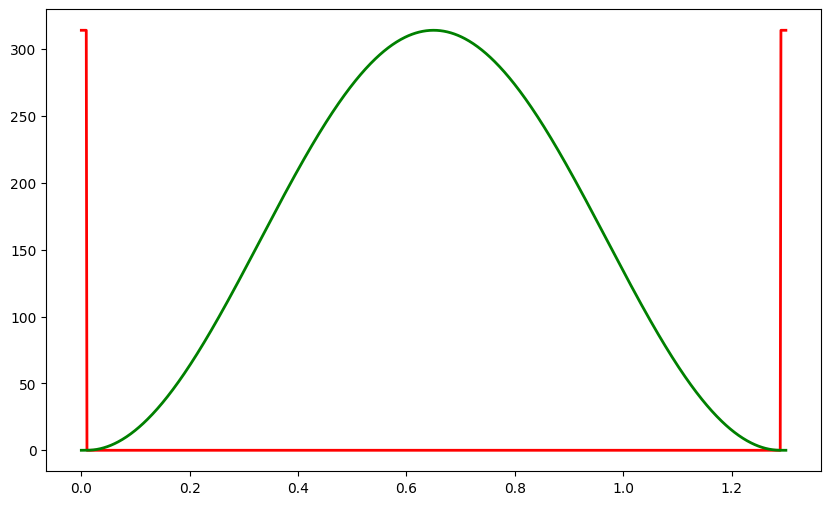

In [60]:
# 可视化函数和积分
t_plot = np.linspace(0, tmax, 1000)
pulse_valuesp = [Omega_p(t) for t in t_plot]
pulse_valuesc = [Omega_r(t) for t in t_plot]
#pulse_values = [Omega_c for t in t_plot]
plt.figure(figsize=(10, 6))
#plt.plot(t_plot, pulse_values, 'b-', linewidth=2, label='Pulse Function')
plt.plot(t_plot, pulse_valuesc, 'r-', linewidth=2, label='Pulse Function')
plt.plot(t_plot, pulse_valuesp, 'g-', linewidth=2, label='Pulse Function')
plt.fill_between(t_plot, pulse_values, alpha=0.3, color='blue', label=f'Integral Area = {integral_value:.6f}')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Pulse Function and its Integral')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
#hc = np.array([[0, 0, 0],
#               [0, 0, omega_c/2],
#               [0, omega_c/2, 0]])

#hrr = np.array([[0, 0, 0],
#                [0, 0, 0],
#                [0, 0, 1]])

#hRR = np.array([[0, 0, 0, 0],
#                [0, 0, 0, 0],
#                [0, 0, 0, 0],
#                [0, 0, 0, 1]])

#hamiltonian
hc = omega_c/2 * (g * r_dag + r * g_dag)
hrr = r * r_dag
hRR = R * R_dag

In [7]:
hRR

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=True
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 1.]]

In [22]:
def ht(t):
    return Omega_p(t)/2 * (P * A_dag + A * P_dag + P * B_dag + B * P_dag) + Omega_c(t)/2 * (P * R_dag + R * P_dag) - Dta * P * P_dag

In [23]:
L_c = np.sqrt(gamma_c) * (g * r_dag)


In [24]:
L_P = np.sqrt(gamma_p) * (A * P_dag + B * P_dag)
L_R = np.sqrt(gamma_R) * (A * R_dag + B * R_dag)

In [25]:
def Hnhermitian(t):
    h1 = tensor(hc, Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), ht(t))
    h2 = V_dd * tensor(hrr, hRR)
    h31 = -1j/2 * (L_c.dag() * L_c)
    h32 = -1j/2 * (L_P.dag() * L_P + L_R.dag() * L_R)
    h3 = tensor(h31, Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), h32)
    return h1 + h2 + h3

In [26]:
Hnhermitian(0.2)

Quantum object: dims=[[2, 4], [2, 4]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[    0.        +0.00000000e+00j     0.        +0.00000000e+00j
     31.75370237+0.00000000e+00j     0.        +0.00000000e+00j
    392.6990817 +0.00000000e+00j     0.        +0.00000000e+00j
      0.        +0.00000000e+00j     0.        +0.00000000e+00j]
 [    0.        +0.00000000e+00j     0.        +0.00000000e+00j
     31.75370237+0.00000000e+00j     0.        +0.00000000e+00j
      0.        +0.00000000e+00j   392.6990817 +0.00000000e+00j
      0.        +0.00000000e+00j     0.        +0.00000000e+00j]
 [   31.75370237+0.00000000e+00j    31.75370237+0.00000000e+00j
  -7539.82236862-7.63358779e+00j     0.        +0.00000000e+00j
      0.        +0.00000000e+00j     0.        +0.00000000e+00j
    392.6990817 +0.00000000e+00j     0.        +0.00000000e+00j]
 [    0.        +0.00000000e+00j     0.        +0.00000000e+00j
      0.        +0.00000000e+00j     0.        -1.98019802e-0

In [27]:
c_ops = tensor(L_c, Qobj(np.eye(4))) + tensor(Qobj(np.eye(2)), L_P) + tensor(Qobj(np.eye(2)), L_R)

In [28]:
c_ops

Quantum object: dims=[[2, 4], [2, 4]], shape=(8, 8), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0.         0.         2.76289482 0.04449942 0.04271788 0.
  0.         0.        ]
 [0.         0.         2.76289482 0.04449942 0.         0.04271788
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.04271788 0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.04271788]
 [0.         0.         0.         0.         0.         0.
  2.76289482 0.04449942]
 [0.         0.         0.         0.         0.         0.
  2.76289482 0.04449942]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.        ]]

In [29]:
psi_0 = tensor(g,A)
psi_1 = tensor(g,B)

In [30]:
mc = mcsolve(Hnhermitian, psi_0, tlist, c_ops, [psi_0*psi_0.dag(), psi_1*psi_1.dag()])


10.0%. Run time: 213.12s. Est. time left: 00:00:31:58
20.0%. Run time: 433.44s. Est. time left: 00:00:28:53
30.0%. Run time: 668.70s. Est. time left: 00:00:26:00
40.0%. Run time: 906.73s. Est. time left: 00:00:22:40
50.0%. Run time: 1148.75s. Est. time left: 00:00:19:08
60.0%. Run time: 1394.72s. Est. time left: 00:00:15:29
70.0%. Run time: 1643.09s. Est. time left: 00:00:11:44
80.0%. Run time: 1895.50s. Est. time left: 00:00:07:53
90.0%. Run time: 2137.22s. Est. time left: 00:00:03:57
100.0%. Run time: 2374.83s. Est. time left: 00:00:00:00
Total run time: 2379.64s


In [31]:
mc



<McResult
  Solver: mcsolve
  Solver stats:
    method: 'adams'
    init time: 0.00015425682067871094
    preparation time: 0.002447843551635742
    run time: 2379.642101049423
    solver: 'Master Equation Evolution'
    num_collapse: 1
    end_condition: 'ntraj reached'
  Time interval: [0.0, 1.2999999999999998] (10 steps)
  Number of e_ops: 2
  State not saved.
  Number of trajectories: 500
  Trajectories not saved.
>

In [49]:
print(mc.expect[0][999])


IndexError: index 999 is out of bounds for axis 0 with size 10

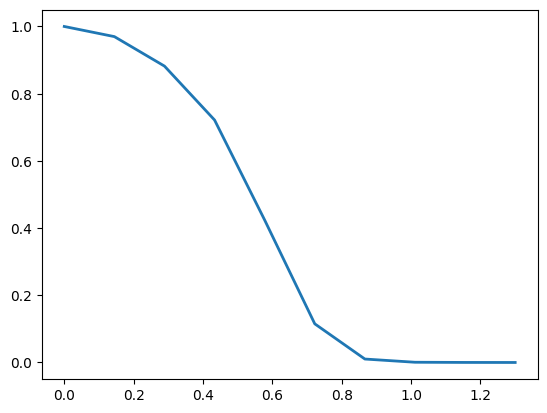

In [51]:
plt.plot(tlist,mc.expect[0],lw=2)

plt.show()

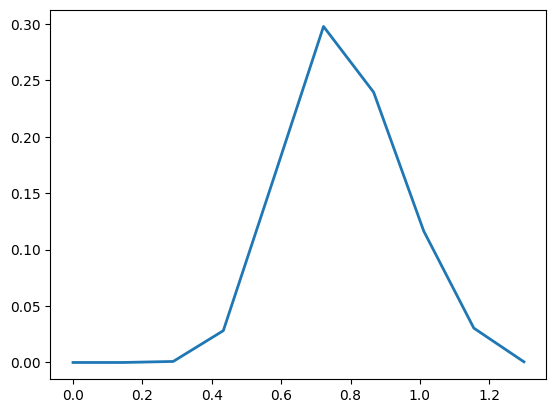

In [52]:
plt.plot(tlist,mc.expect[1],lw=2)

plt.show()